# Thesis figures: simulated models

This notebook loads the saved PTO, DFL, and black-box simulation results directly. It is separate from the horserace evaluation notebook and is intended for producing clean figures for the thesis write-up.

In [15]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'simulation' / 'data' / 'simulated_pd_panel.csv').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from minou_colors import MINOU_COLORS

RESULTS_DIR = ROOT / 'simulation' / 'results'
FIGURES_DIR = ROOT / 'simulation' / 'figures' / '07_thesis_figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def load_result(folder, prefix):
    path = RESULTS_DIR / folder / f'{prefix}_sim_predictions_main.csv'
    if not path.exists():
        raise FileNotFoundError(f'Missing {path}; run the corresponding model notebook first.')
    out = pd.read_csv(path, parse_dates=['date']).sort_values('date').reset_index(drop=True)
    out['t'] = np.arange(1, len(out) + 1)
    print(f'{prefix}: {len(out)} rows from {path.relative_to(ROOT)}')
    return out

pto = load_result('02_pto', 'pto')
dfl = load_result('04_dfl', 'dfl')
blackbox = load_result('03_blackbox', 'blackbox')

pto: 300 rows from simulation/results/02_pto/pto_sim_predictions_main.csv
dfl: 300 rows from simulation/results/04_dfl/dfl_sim_predictions_main.csv
blackbox: 300 rows from simulation/results/03_blackbox/blackbox_sim_predictions_main.csv


In [16]:
# Thesis plotting defaults.
plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 300, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.22, 'grid.linewidth': 0.6,
})
COLORS = {
    'truth': MINOU_COLORS['navy'],
    'model': MINOU_COLORS['teal'],
    'oracle': MINOU_COLORS['coral'],
    'regret': MINOU_COLORS['coral'],
    'blackbox': MINOU_COLORS['navy'],
    'dfl': MINOU_COLORS['sage'],
}

def finish(ax, ylabel=None):
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.margins(x=0.01)
    ax.grid(True, alpha=0.28)

def allocation_limits(frame, keys, tolerance=0.08):
    # Use the observed alpha range and add a small tolerance so the lines fill the axis.
    values = np.concatenate([frame[key].to_numpy(dtype=float) for key in keys])
    lo, hi = float(np.nanmin(values)), float(np.nanmax(values))
    span = hi - lo
    pad = max(0.01, tolerance * span) if span else max(0.01, tolerance * max(abs(lo), 1.0))
    return lo - pad, hi + pad

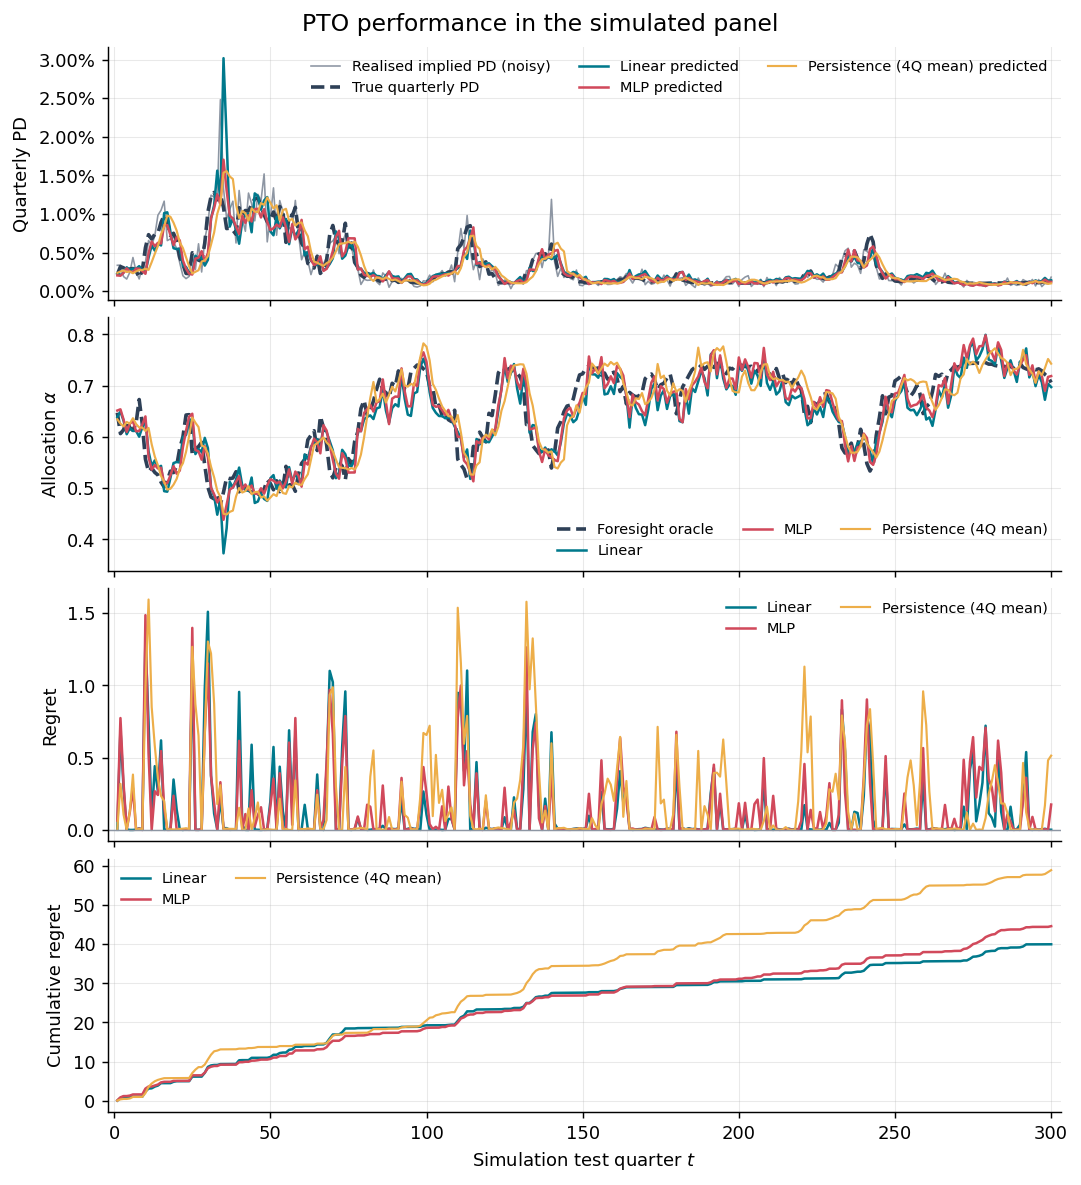

Saved simulation/figures/07_thesis_figures/pto_mlp_four_panel.png


In [17]:
# Main PTO four-panel thesis figure.
fig, axes = plt.subplots(4, 1, figsize=(8.2, 9.0), sharex=True, constrained_layout=True)

MODEL_SPECS = {
    'linear': ('Linear', MINOU_COLORS['teal'], 1.4),
    'mlp': ('MLP', MINOU_COLORS['coral'], 1.4),
    'persistence': ('Persistence (raw draw)', MINOU_COLORS['grey'], 0.8),
    'persistence_ma4': ('Persistence (4Q mean)', MINOU_COLORS['gold'], 1.2),
}
PLOT_MODELS = ['linear', 'mlp', 'persistence_ma4']
SHOW_BAYES_ORACLE = False
models = [(key, *MODEL_SPECS[key]) for key in PLOT_MODELS]
axes[0].plot(pto['t'], pto['pd_q_realised'], color=MINOU_COLORS['grey'], lw=0.9, label='Realised implied PD (noisy)')
axes[0].plot(pto['t'], pto['pd_q_true'], color=MINOU_COLORS['navy'], lw=2, ls='--', label='True quarterly PD')
for key, label, color, lw in models:
    axes[0].plot(pto['t'], pto[f'pd_q_hat_{key}'], color=color, lw=lw, label=f'{label} predicted')
finish(axes[0], 'Quarterly PD')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].legend(frameon=False, ncol=3, fontsize=8, loc='upper right')

axes[1].plot(pto['t'], pto['alpha_oracle'], color=MINOU_COLORS['navy'], lw=2, ls='--', label='Foresight oracle')
if SHOW_BAYES_ORACLE:
    axes[1].plot(pto['t'], pto['alpha_bayes'], color=MINOU_COLORS['sage'], lw=1.6, ls=':', label='Bayes oracle')
for key, label, color, lw in models:
    axes[1].plot(pto['t'], pto[f'alpha_hat_{key}'], color=color, lw=lw, label=label)
finish(axes[1], 'Allocation $\\alpha$')
axes[1].set_ylim(*allocation_limits(pto, ['alpha_oracle'] + [f'alpha_hat_{key}' for key, *_ in models]))
axes[1].legend(frameon=False, ncol=3, fontsize=8, loc='lower right')

for key, label, color, lw in models:
    axes[2].plot(pto['t'], pto[f'regret_{key}'], color=color, lw=lw, label=label)
axes[2].axhline(0, color=MINOU_COLORS['grey'], lw=0.8)
finish(axes[2], 'Regret')
axes[2].legend(frameon=False, ncol=2, fontsize=8)

for key, label, color, lw in models:
    axes[3].plot(pto['t'], pto[f'regret_{key}'].cumsum(), color=color, lw=lw, label=label)
finish(axes[3], 'Cumulative regret')
axes[3].legend(frameon=False, ncol=2, fontsize=8)
axes[3].set_xlabel(r'Simulation test quarter $t$')
fig.suptitle('PTO performance in the simulated panel', fontsize=13)
pto_path = FIGURES_DIR / 'pto_mlp_four_panel.png'
fig.savefig(pto_path, bbox_inches='tight')
plt.show()
print(f'Saved {pto_path.relative_to(ROOT)}')

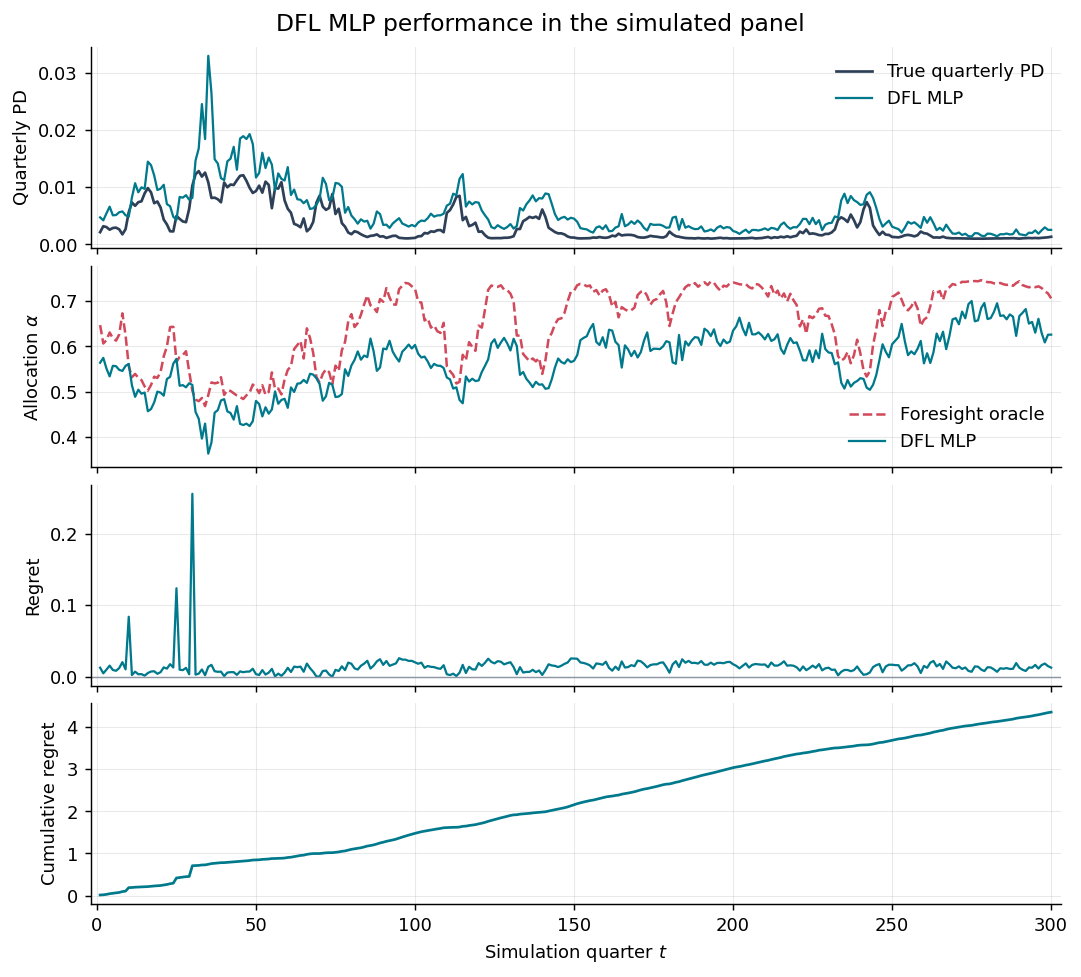

Saved simulation/figures/07_thesis_figures/dfl_mlp_four_panel.png


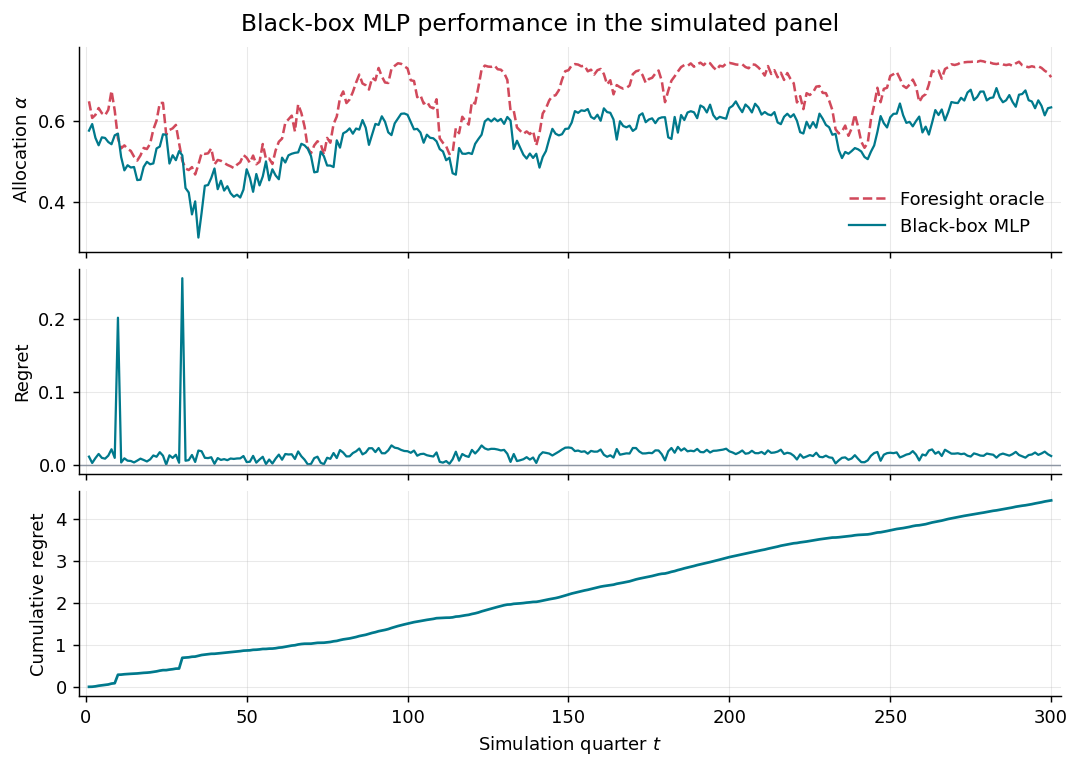

Saved simulation/figures/07_thesis_figures/blackbox_mlp_three_panel.png


In [18]:
# Compact comparable panels for DFL and black-box models.
def model_panel(frame, model_key, label, path_name, has_pd=True):
    fig, axes = plt.subplots(4 if has_pd else 3, 1, figsize=(8.2, 7.4 if has_pd else 5.8), sharex=True, constrained_layout=True)
    if has_pd:
        axes[0].plot(frame['t'], frame['pd_q_true'], color=COLORS['truth'], lw=1.5, label='True quarterly PD')
        axes[0].plot(frame['t'], frame[f'pd_q_hat_{model_key}'], color=COLORS['model'], lw=1.25, label=label)
        finish(axes[0], 'Quarterly PD'); axes[0].legend(frameon=False)
        offset = 1
    else:
        offset = 0
    axes[offset].plot(frame['t'], frame['alpha_oracle'], color=COLORS['oracle'], lw=1.4, ls='--', label='Foresight oracle')
    axes[offset].plot(frame['t'], frame[f'alpha_hat_{model_key}'], color=COLORS['model'], lw=1.25, label=label)
    finish(axes[offset], 'Allocation $\\alpha$'); axes[offset].set_ylim(*allocation_limits(frame, ['alpha_oracle', f'alpha_hat_{model_key}'])); axes[offset].legend(frameon=False)
    axes[offset + 1].plot(frame['t'], frame[f'regret_{model_key}'], color=COLORS['model'], lw=1.25, label=label)
    axes[offset + 1].axhline(0, color=MINOU_COLORS['grey'], lw=0.8)
    finish(axes[offset + 1], 'Regret')
    axes[offset + 2].plot(frame['t'], frame[f'regret_{model_key}'].cumsum(), color=COLORS['model'], lw=1.5)
    finish(axes[offset + 2], 'Cumulative regret'); axes[offset + 2].set_xlabel(r'Simulation quarter $t$')
    fig.suptitle(f'{label} performance in the simulated panel', fontsize=13)
    path = FIGURES_DIR / path_name
    fig.savefig(path, bbox_inches='tight')
    plt.show()
    print(f'Saved {path.relative_to(ROOT)}')
    return fig

dfl_fig = model_panel(dfl, 'dfl_mlp', 'DFL MLP', 'dfl_mlp_four_panel.png', has_pd=True)
bb_fig = model_panel(blackbox, 'blackbox_mlp', 'Black-box MLP', 'blackbox_mlp_three_panel.png', has_pd=False)

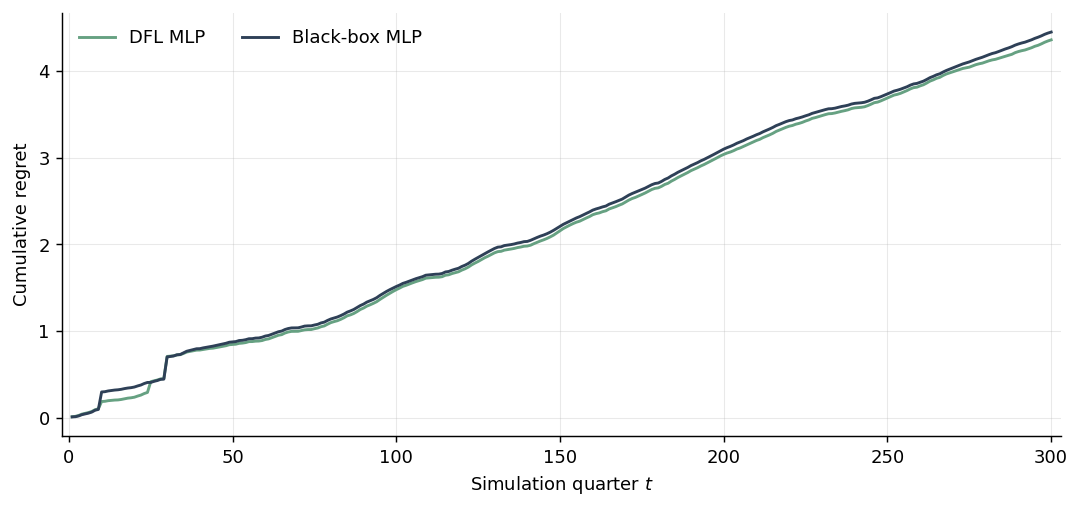

Saved simulation/figures/07_thesis_figures/cumulative_regret_dfl_vs_blackbox.png


In [19]:
# One direct comparison of cumulative regret. Set this to True to compare only DFL and black-box.
DFL_VS_BLACKBOX_ONLY = True
fig, ax = plt.subplots(figsize=(8.2, 3.8), constrained_layout=True)
comparison_models = [(dfl, 'dfl_mlp', 'DFL MLP', COLORS['dfl']), (blackbox, 'blackbox_mlp', 'Black-box MLP', COLORS['blackbox'])] if DFL_VS_BLACKBOX_ONLY else [(pto, 'mlp', 'PTO MLP', COLORS['model']), (dfl, 'dfl_mlp', 'DFL MLP', COLORS['dfl']), (blackbox, 'blackbox_mlp', 'Black-box MLP', COLORS['blackbox'])]
for frame, key, label, color in comparison_models:
    ax.plot(frame['t'], frame[f'regret_{key}'].cumsum(), lw=1.6, label=label, color=color)
finish(ax, 'Cumulative regret'); ax.set_xlabel(r'Simulation quarter $t$'); ax.legend(frameon=False, ncol=3)
comparison_name = 'dfl_vs_blackbox' if DFL_VS_BLACKBOX_ONLY else 'headline_models'
path = FIGURES_DIR / f'cumulative_regret_{comparison_name}.png'
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f'Saved {path.relative_to(ROOT)}')

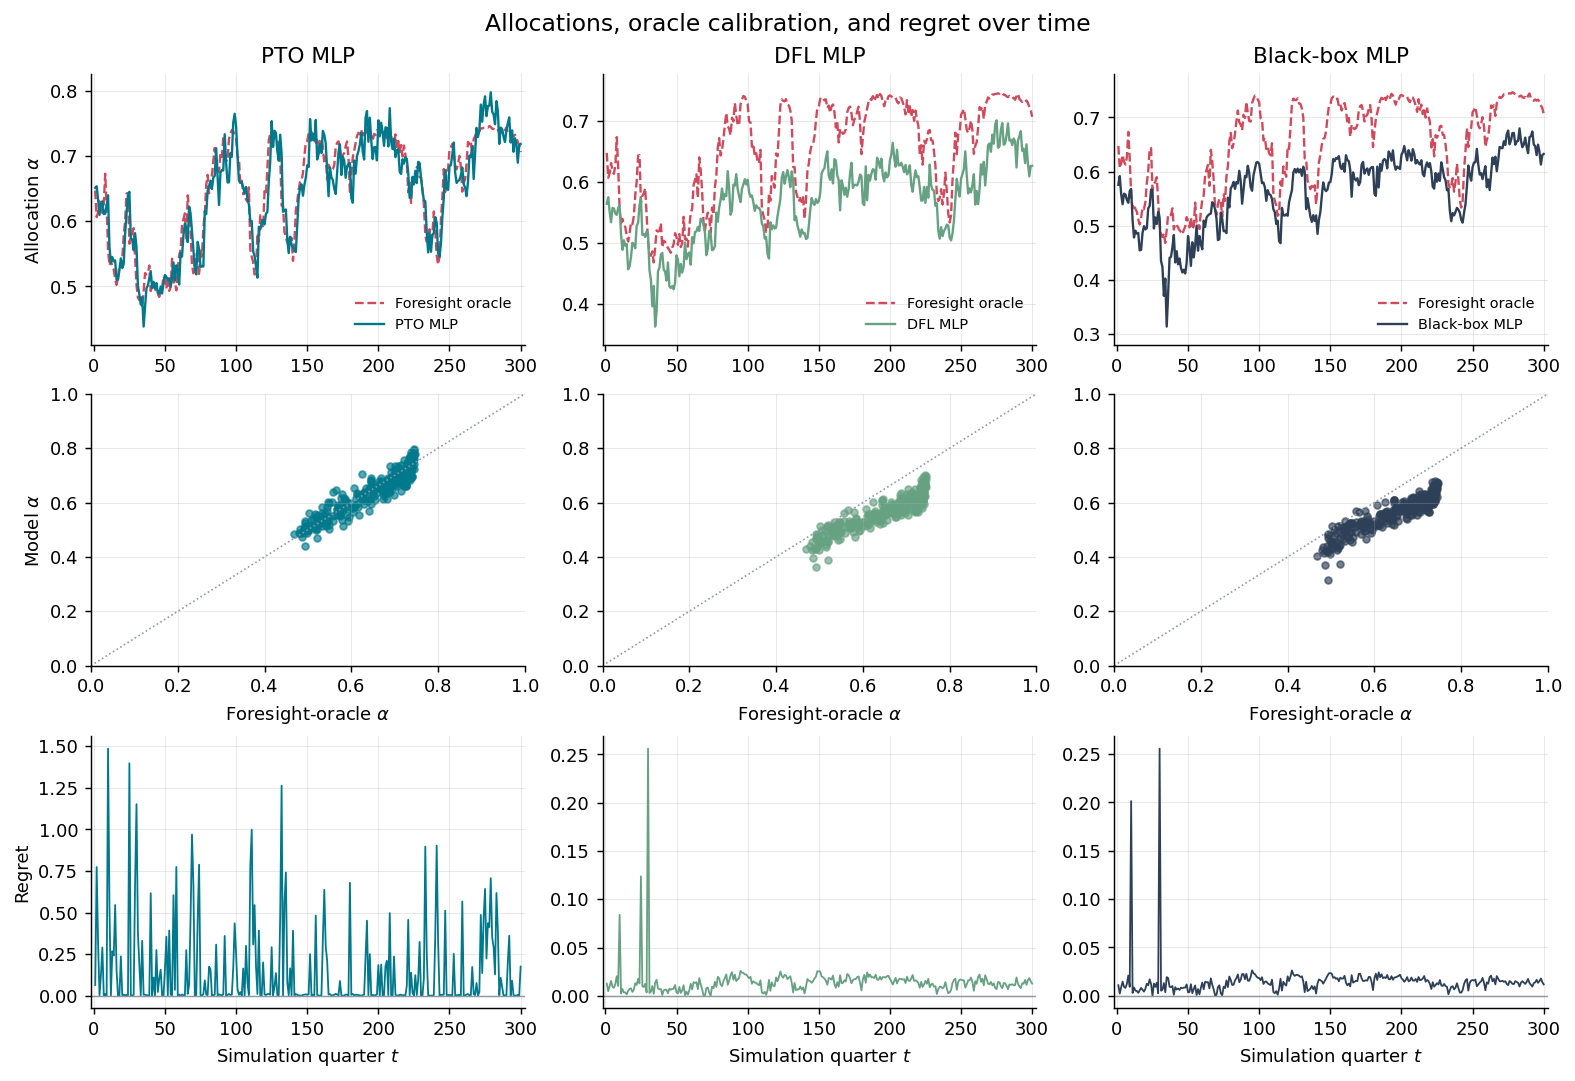

Saved simulation/figures/07_thesis_figures/allocations_and_regret_by_model.png


In [ ]:
# Side-by-side allocation comparison with model-specific regret below each allocation.
allocation_models = [
    (pto, 'mlp', 'PTO MLP', COLORS['model']),
    (dfl, 'dfl_mlp', 'DFL MLP', COLORS['dfl']),
    (blackbox, 'blackbox_mlp', 'Black-box MLP', COLORS['blackbox']),
]
fig, axes = plt.subplots(3, 3, figsize=(12.0, 8.2), constrained_layout=True)
for col, (frame, key, label, color) in enumerate(allocation_models):
    axes[0, col].plot(frame['t'], frame['alpha_oracle'], color=COLORS['oracle'], lw=1.3, ls='--', label='Foresight oracle')
    axes[0, col].plot(frame['t'], frame[f'alpha_hat_{key}'], color=color, lw=1.3, label=label)
    axes[0, col].set_title(label)
    axes[0, col].set_ylim(*allocation_limits(frame, ['alpha_oracle', f'alpha_hat_{key}']))
    finish(axes[0, col], 'Allocation $\\alpha$' if col == 0 else None)
    axes[0, col].legend(frameon=False, fontsize=8)
    axes[1, col].scatter(frame['alpha_oracle'], frame[f'alpha_hat_{key}'], s=14, color=color, alpha=0.65)
    axes[1, col].plot([0, 1], [0, 1], color=MINOU_COLORS['grey'], lw=0.9, ls=':')
    axes[1, col].set_xlim(0, 1); axes[1, col].set_ylim(0, 1)
    axes[1, col].set_xlabel(r'Foresight-oracle $\alpha$')
    finish(axes[1, col], r'Model $\alpha$' if col == 0 else None)
    axes[2, col].plot(frame['t'], frame[f'regret_{key}'], color=color, lw=1.0)
    axes[2, col].axhline(0, color=MINOU_COLORS['grey'], lw=0.8)
    finish(axes[2, col], 'Regret' if col == 0 else None)
    axes[2, col].set_xlabel(r'Simulation test quarter $t$')
fig.suptitle('Allocations, oracle calibration, and regret over time', fontsize=13)
path = FIGURES_DIR / 'allocations_and_regret_by_model.png'
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f'Saved {path.relative_to(ROOT)}')
